# Class 04 — Feature Scaling Techniques · Feature Engineering Strategies



---

## Class Agenda

1. Why scaling matters — models that need it vs models that don't
2. **Standardization** (Z-score / StandardScaler)
3. **Normalization** — Min-Max, MaxAbs, L2-norm
4. **RobustScaler** for outlier-heavy features
5. Effect of scaling on linear models, KNN, SVM, PCA, gradient descent, trees
6. Feature transformation — **log, Box-Cox, Yeo-Johnson, QuantileTransformer**
7. Feature engineering strategies — interactions, ratios, polynomial, binning, datetime, aggregations
8. Production pipeline: scaling + transforms + interactions, leakage-free


## Why This Topic Matters

**Importance in ML** — Distance- and gradient-based models (KNN, SVM, k-Means, neural nets, regularized linear models) are *unusable* without scaling. Feature engineering is consistently the highest-ROI activity in tabular ML — better features beat better models.

**Importance in AI Systems** — Embeddings, attention weights, and gradient magnitudes all assume comparable input scales. Mis-scaled features cause exploding/vanishing gradients in deep nets.

**Importance in Production ML** — Scalers must be **fit on train, applied at inference**. Any mismatch is the #1 source of training-serving skew.

**Importance in Interviews** — *"Why does Ridge need scaling but Random Forest doesn't?"* — a canonical FAANG question testing whether you understand the model, not just sklearn.

**Real-World Relevance** — Uber's ETA model uses log-transformed durations + cyclical hour encoding; Airbnb's price model uses log-price; Stripe Radar uses signed-log on `amount`.


## Learning Outcomes

1. State which model families require feature scaling and why.
2. Apply **StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer** appropriately.
3. Recognize when **log / Box-Cox / Yeo-Johnson / QuantileTransformer** is preferred.
4. Engineer **interaction features**, ratios, and polynomial expansions.
5. Engineer **datetime features** with cyclical (sin/cos) encoding.
6. Engineer **aggregation features** (groupby means/counts/recency).
7. Build a leakage-free `Pipeline` that scales + transforms + engineers features.
8. Diagnose scaling-related bugs (NaN, inf, divergence).
9. Quantify the lift from feature engineering vs model tuning.
10. Justify scaling/transformation choices in a model review.


## 1. Why Scaling Matters

| Model | Needs scaling? | Reason |
|-------|----------------|--------|
| Linear / Logistic Regression (regularized) | **Yes** | Penalty shrinks larger-scale features more |
| Linear / Logistic Regression (unregularized) | No (theoretically) | invariant under linear rescale — but GD converges faster if scaled |
| **KNN, K-Means, SVM (RBF)** | **Yes** | distance metric dominated by large-scale features |
| **PCA** | **Yes** | maximizes variance — biased toward high-variance scales |
| Neural networks | **Yes** | gradients, initialization scales assume O(1) inputs |
| **Tree-based (DT, RF, GBM, XGB, LGBM, CatBoost)** | No | splits are scale-invariant |
| Naive Bayes (Gaussian) | mild | only affects per-feature Gaussians, not class boundary |

> **Example.** Predicting house price from `sqft` (range 500-5000) and `bedrooms` (range 1-6). In KNN, distance is dominated by `sqft`; `bedrooms` becomes invisible. After standardization, both features contribute on equal footing.


In [ ]:
# Example — KNN with vs without scaling
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X, y = load_breast_cancer(return_X_y=True)
print("KNN no scaling :", cross_val_score(KNeighborsClassifier(), X, y, cv=5).mean().round(3))
print("KNN + scaling  :", cross_val_score(Pipeline([("s", StandardScaler()),
                                                    ("k", KNeighborsClassifier())]),
                                          X, y, cv=5).mean().round(3))


KNN no scaling : 0.928
KNN + scaling  : 0.965


## 2. Standardization (Z-score)

$$ z = \frac{x - \mu}{\sigma}. $$

Resulting feature has mean 0, std 1.

- ✅ Default for linear / logistic / SVM / NN.
- ❌ Sensitive to outliers (one extreme value distorts $\mu, \sigma$).
- Doesn't bound the range — values can be ±10.

> **Example.** Standardizing `income` (mean $60k, std $30k): $30k → -1.0, $120k → +2.0.


In [ ]:
# Example — StandardScaler
import numpy as np
from sklearn.preprocessing import StandardScaler
X = np.array([[100], [200], [300], [400], [500]], dtype=float)
print(StandardScaler().fit_transform(X).ravel())


## 3. Normalization — Min-Max / MaxAbs / L2

**MinMaxScaler:** $x' = (x - x_{\min}) / (x_{\max} - x_{\min}) \in [0, 1]$ — useful when bounded inputs are required (image pixels, NN with sigmoid).

**MaxAbsScaler:** $x' = x / |x|_{\max} \in [-1, 1]$ — preserves zero/sparsity, good for sparse matrices (text TF-IDF).

**Normalizer (L2)** scales each *row* to unit norm — used in text similarity / cosine retrieval, **not** for tabular features.

> **Example.** Pixel intensities 0-255 → MinMax to [0,1] for a CNN; TF-IDF sparse matrix → MaxAbs to preserve sparsity.


In [ ]:
# Example — compare scalers
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
x = np.array([[1.],[2.],[3.],[4.],[100.]])   # has an outlier
out = pd.DataFrame({
    "raw":     x.ravel(),
    "Std":     StandardScaler().fit_transform(x).ravel().round(2),
    "MinMax":  MinMaxScaler().fit_transform(x).ravel().round(2),
    "MaxAbs":  MaxAbsScaler().fit_transform(x).ravel().round(2),
    "Robust":  RobustScaler().fit_transform(x).ravel().round(2),
})
print(out)


     raw   Std  MinMax  MaxAbs  Robust
0    1.0 -0.54    0.00    0.01    -1.0
1    2.0 -0.51    0.01    0.02    -0.5
2    3.0 -0.49    0.02    0.03     0.0
3    4.0 -0.46    0.03    0.04     0.5
4  100.0  2.00    1.00    1.00    48.5


## 4. RobustScaler — for outliers

$$ x' = \frac{x - \text{median}(x)}{\text{IQR}(x)}. $$

Uses median and IQR instead of mean and std → unaffected by extreme values. Default scaler when outliers are real and you don't want to clip them.

> **Example.** Web request latencies have long right tails (P99 ≫ mean). StandardScaler squashes the bulk near 0 and leaves the tail at +50σ. RobustScaler keeps the bulk meaningfully spread.


## 5. Effect of Scaling — model-by-model

- **Regularized linear (Ridge/Lasso/Logistic)** — penalty is per-coefficient; unscaled features get unequal regularization. **Always scale.**
- **KNN / K-Means / SVM-RBF** — Euclidean distance is unit-dependent. **Always scale.**
- **PCA** — variance is unit-dependent. **Always scale** (unless features share units).
- **Gradient descent** — convergence speed depends on the loss curvature's condition number; scaling makes it spherical. **Always scale** for NN / linear-GD.
- **Trees / GBM** — splits are based on rank order, scale-invariant. **No scaling needed.**

> **Example.** Without scaling, PCA on (`sqft`, `bedrooms`) returns PC1 ≈ `sqft` and explains 99.99% variance — a useless decomposition.


In [ ]:
# Example — PCA with vs without scaling
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(0)
X = np.c_[rng.normal(2500, 800, 500), rng.normal(3, 1, 500)]   # sqft, bedrooms
print("Unscaled PCA variance ratio:", PCA(2).fit(X).explained_variance_ratio_.round(4))
Xs = StandardScaler().fit_transform(X)
print("Scaled   PCA variance ratio:", PCA(2).fit(Xs).explained_variance_ratio_.round(4))


Unscaled PCA variance ratio: [1. 0.]
Scaled   PCA variance ratio: [0.5026 0.4974]


## 6. Feature Transformation

Make distributions more symmetric / Gaussian-like — helps linear models and stabilizes variance.

| Transform | Domain | When to use |
|-----------|--------|-------------|
| **log / log1p** | $x > 0$ | right-skewed positive (price, income, counts) |
| **Box-Cox** | $x > 0$ | finds best power $\lambda$ automatically |
| **Yeo-Johnson** | any real $x$ | Box-Cox generalized to negatives |
| **QuantileTransformer** | any | maps to uniform or Gaussian via empirical CDF; very robust |
| **Reciprocal** $1/x$ | $x \ne 0$ | converts rate ↔ duration |

> **Example.** House prices are right-skewed; modeling `log(price)` gives symmetric errors and makes RMSE behave like a *percentage* error.


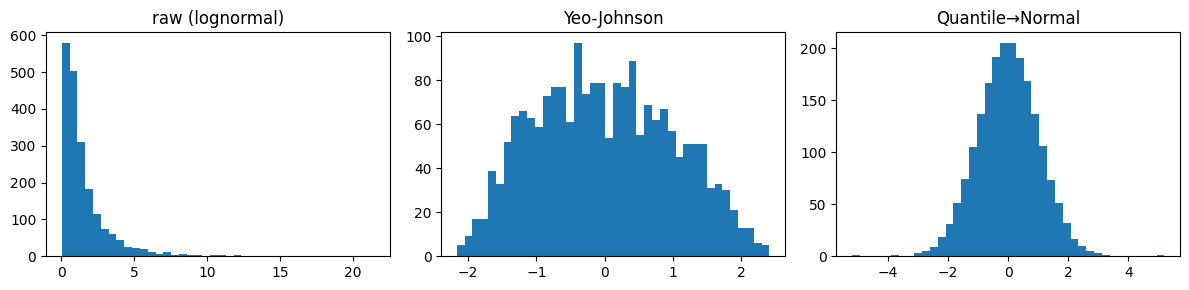

In [ ]:
# Example — Yeo-Johnson and QuantileTransformer
import numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
rng = np.random.default_rng(0)
x = rng.lognormal(0, 1, 2000).reshape(-1, 1)

yj = PowerTransformer(method="yeo-johnson").fit_transform(x)
qt = QuantileTransformer(output_distribution="normal", random_state=0).fit_transform(x)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, data, title in zip(ax, [x, yj, qt], ["raw (lognormal)", "Yeo-Johnson", "Quantile→Normal"]):
    a.hist(data, bins=40); a.set_title(title)
plt.tight_layout(); plt.show()


## 7. Feature Engineering Strategies

The highest-leverage step in tabular ML. Categories:

### a) Interactions
Products / ratios of features that capture *combined* effects.

- `price_per_sqft = price / sqft`
- `clicks * impressions` (engagement strength)
- `is_weekend AND is_evening` (joint context)

> **Example.** Predicting credit default: `debt / income` is far more predictive than either alone.

### b) Polynomial features
`PolynomialFeatures(degree=2)` generates $x_i, x_i^2, x_i x_j$ — pair with Ridge to control variance.

### c) Binning / discretization
Convert continuous → categorical to capture non-linear effects in linear models:
- `age` → `[0-17, 18-25, 26-40, 41-60, 60+]`
- `KBinsDiscretizer(strategy="quantile")`

### d) Datetime features
Extract `year, month, day, hour, dow, is_weekend, is_holiday`. For periodic effects use **cyclical encoding**:

$$ \sin\!\left(\frac{2\pi t}{T}\right), \quad \cos\!\left(\frac{2\pi t}{T}\right) $$

so that hour 23 is close to hour 0.

### e) Aggregation features
`user → mean(last 7d order value)`, `merchant → count(distinct cards last 1h)`. These are the *features that win Kaggle*.

> **Example.** Fraud detection: `count(transactions, same_card, last_5_min)` is one of the strongest features in any payment-fraud stack.


In [ ]:
# Example — cyclical datetime + ratio interaction
import numpy as np, pandas as pd
ts = pd.date_range("2024-01-01", periods=500, freq="h")
df = pd.DataFrame({"ts": ts, "price": np.random.default_rng(0).gamma(2, 50, 500),
                   "sqft": np.random.default_rng(1).normal(2000, 400, 500)})
df["hour"] = df["ts"].dt.hour
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["dow"]      = df["ts"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["price_per_sqft"] = df["price"] / df["sqft"]
print(df.head())


                   ts       price         sqft  hour  hour_sin  hour_cos  dow  \
0 2024-01-01 00:00:00   91.715503  2138.233677     0  0.000000  1.000000    0   
1 2024-01-01 01:00:00  131.884899  2328.647257     1  0.258819  0.965926    0   
2 2024-01-01 02:00:00   53.317904  2132.174830     2  0.500000  0.866025    0   
3 2024-01-01 03:00:00  199.027084  1478.737107     3  0.707107  0.707107    0   
4 2024-01-01 04:00:00   45.661543  2362.142347     4  0.866025  0.500000    0   

   is_weekend  price_per_sqft  
0           0        0.042893  
1           0        0.056636  
2           0        0.025006  
3           0        0.134593  
4           0        0.019331  


In [ ]:
# Example — interaction + polynomial features
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
X = np.array([[1, 2], [3, 4], [5, 6]])
print("Original :\n", X)
print("Poly d=2 (interaction_only):\n",
      PolynomialFeatures(2, interaction_only=True, include_bias=False).fit_transform(X))
print("Poly d=2 (full):\n",
      PolynomialFeatures(2, include_bias=False).fit_transform(X))


Original :
 [[1 2]
 [3 4]
 [5 6]]
Poly d=2 (interaction_only):
 [[ 1.  2.  2.]
 [ 3.  4. 12.]
 [ 5.  6. 30.]]
Poly d=2 (full):
 [[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]
 [ 5.  6. 25. 30. 36.]]


In [ ]:
# Example — aggregation feature (groupby)
import pandas as pd, numpy as np
rng = np.random.default_rng(0)
df = pd.DataFrame({
    "user_id": rng.integers(0, 50, 500),
    "amount":  rng.gamma(2, 30, 500),
})
agg = df.groupby("user_id")["amount"].agg(["mean", "std", "count"]).add_prefix("user_amt_")
df = df.merge(agg, on="user_id", how="left")
print(df.head())


   user_id      amount  user_amt_mean  user_amt_std  user_amt_count
0       42   58.119362      67.179531     28.497868               9
1       31  228.315353      57.317719     60.959570              15
2       25   16.048549      54.569637     37.601332              12
3       13   48.510957      54.549868     31.181954              15
4       15   22.125597      83.909712     70.663745              12


## 8. Production Pipeline — combined

Everything together: capping is data cleaning (Class 3), then scale + transform + engineer features → model. Persist as **one artifact**.


In [ ]:
# Example — scaling + Yeo-Johnson + interactions inside a Pipeline
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, PowerTransformer,
                                   PolynomialFeatures)
from sklearn.linear_model import RidgeCV

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, random_state=0)

pipe = Pipeline([
    ("yj",   PowerTransformer(method="yeo-johnson")),
    ("std",  StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("m",    RidgeCV(alphas=np.logspace(-2, 3, 20))),
]).fit(Xtr, ytr)

print(f"Test R^2  : {pipe.score(Xte, yte):.4f}")
print(f"Test RMSE : {((pipe.predict(Xte)-yte)**2).mean()**0.5:.4f}")


Test R^2  : 0.7182
Test RMSE : 0.6062


## Tradeoffs & Pitfalls

- **Fitting scaler on full dataset** → leakage. Always fit on train inside a Pipeline.
- **Scaling targets** for regression is fine, but you must inverse-transform predictions (`TransformedTargetRegressor`).
- **MinMax on outlier-heavy data** squashes the bulk to near-zero.
- **Polynomial blowup** — degree 3 on 50 features → 23k features. Pair with regularization or feature selection.
- **Datetime as int** (epoch seconds) into a linear model is a recipe for nonsense.
- **Interaction explosion** — be selective; use domain knowledge or `mutual_info_regression` to prune.

## Production Considerations

- Persist scaler statistics (mean/std/median/IQR) as part of the model artifact.
- Monitor each scaled feature's distribution post-scaling (should stay roughly N(0,1)).
- For online features (rolling counts/aggregations), use the **same windowing logic** offline and online — this is the canonical training-serving skew bug.
- Use feature stores (Feast, Tecton) for non-trivial aggregation features.

